### 加载数据

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from sklearn.model_selection import train_test_split
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
# 转换为线性收益率
X = prices_to_returns(prices, drop_inceptions_nan=False)
# Inf值检查
inf_cols = X.columns[np.isinf(X).any(axis=0)]
print(inf_cols.tolist())
# 异常收益检查
X = X.drop(columns=(bad := X.columns[(X.abs() > 0.25).any()])); 
print(f"数据异常：收益率超过±30%的列已剔除 {len(bad)} 列 -> {bad.tolist()}")

[]
数据异常：收益率超过±30%的列已剔除 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']


### 预筛选
对初始资产宇宙进行预选择处理，其核心目的是在构建投资组合之前，通过特定的规则筛选出符合条件的资产，从而优化后续的计算效率和模型表现。

In [3]:
from Pre_selection import DropTailCorrelated
from skfolio.pre_selection import SelectKExtremes
from skfolio.pre_selection import DropZeroVariance, DropCorrelated
from skfolio.pre_selection import SelectComplete, SelectNonExpiring, SelectNonDominated
from skfolio import RiskMeasure,PerfMeasure,RatioMeasure
from sklearn.pipeline import Pipeline

In [ ]:
252//2 252*2
{'correlate__threshold': 0.1, 'nondomin__fitness_measures': [Mean, Average Drawdown], 'nondomin__min_n_assets': 10, 'nondomin__threshold': -0.5}
0.09893299218882344

In [4]:
param_dict = {'correlate__threshold': 0.1, 
              'nondomin__fitness_measures': [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN], 
              'nondomin__min_n_assets': 5,
               'nondomin__threshold': -0.5}

In [5]:
selection_pipe = Pipeline([
        ("complete", SelectComplete(drop_assets_with_internal_nan=False)),
        ("variance", DropZeroVariance(threshold=1e-8)),
        ("nondomin", SelectNonDominated(min_n_assets=param_dict['nondomin__min_n_assets'], 
                                        threshold=param_dict['nondomin__threshold'],
                                        fitness_measures=param_dict['nondomin__fitness_measures'])),
        ("correlate", DropCorrelated(threshold=param_dict['correlate__threshold'], absolute=False)),
    ])

### WalkForward+CombinatorialPurgedCV
组合净化交叉验证生成多个测试路径，以进行更稳健的时间序列模型评估和分布分析。

In [6]:
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure,PerfMeasure,RatioMeasure
from skfolio.metrics import make_scorer
from skfolio.optimization import EqualWeighted
from skfolio.model_selection import WalkForward
from skfolio.model_selection import CombinatorialPurgedCV, cross_val_predict

In [7]:
def fasted_walkforward_cpcv(
    X: pd.DataFrame,
    train_size: int,
    test_size: int,
    n_folds: int,
    n_test_folds: int,
    out_purged_size: int = 0,
    reduce_test: bool = False,
    expand_train: bool = False,
    in_purged_size: int = 2,
    in_embargo_size: int = 2,
    verbose: bool = True,
):
    """WalkForward(外) × CombinatorialPurgedCV(内) 嵌套交叉验证。

    外循环: WalkForward 滚动窗口, 每个 fold 把 train+test 拼成时间连续块;
    内层: 对整个窗口直接调用 cross_val_predict, 由它完成 CPCV 各 split 的
          预筛选→拟合→测试块预测, 不再单独对训练集做预测。

    返回:
        result: {outer_fold: {path_id: MultiPeriodPortfolio}}
        path_result: {outer_fold: {path_id: [Portfolio, ...]}}
    """
    outer_cv = WalkForward(
        test_size=test_size,
        train_size=train_size,
        purged_size=out_purged_size,
        reduce_test=reduce_test,
        expand_train=expand_train,
    )
    inner_cv = CombinatorialPurgedCV(
        n_folds=n_folds, n_test_folds=n_test_folds,
        purged_size=in_purged_size, embargo_size=in_embargo_size,
    )
    # cross_val_predict 要求最后一步是优化器: 预筛选 + 等权拼成完整 pipeline
    # （内部会对 estimator clone, 不会污染全局 selection_pipe）
    model = Pipeline([*selection_pipe.steps, ("optimization", EqualWeighted())])

    result = {}
    path_result = {}

    for i, (train_index, test_index) in enumerate(outer_cv.split(X)):
        # ---- 1) train + test 拼成时间连续窗口 ----
        window_index = np.concatenate([train_index, test_index])
        X_window = X.iloc[window_index]

        # ---- 2) 内层 CPCV 一次完成: 返回 Population, 每个 path 一支 MultiPeriodPortfolio ----
        cvp = cross_val_predict(
            model, X_window, cv=inner_cv, n_jobs=4,
            portfolio_params=dict(name=f"WF{i}"),
        )

        # ---- 3) 按 path_id 组织结果 ----
        result[i] = {pid: mptf for pid, mptf in enumerate(cvp)}
        path_result[i] = {pid: list(mptf) for pid, mptf in enumerate(cvp)}

        if verbose:
            print(
                f"Outer fold {i}: window={len(X_window)} obs | "
                f"inner splits={inner_cv.get_n_splits(X_window)} | "
                f"paths={len(cvp)}"
            )

    return result, path_result


In [ ]:
def nested_walkforward_cpcv(
    X: pd.DataFrame,
    outer_cv: WalkForward | None = None,
    inner_cv: CombinatorialPurgedCV | None = None,
    verbose: bool = True,
):
    """WalkForward(外) × CombinatorialPurgedCV(内) 嵌套交叉验证。

    外循环: WalkForward 滚动窗口, 每个 fold 把 train+test 拼成时间连续块;
    内循环: 在该连续块上做 CPCV, 每个组合都走预筛选→拟合→多测试块预测。
    """
    if outer_cv is None:
        outer_cv = WalkForward(
            test_size=252,
            train_size=int(252 * 3),
            purged_size=0,
            reduce_test=False,
            expand_train=False,
        )
    if inner_cv is None:
        inner_cv = CombinatorialPurgedCV(
            n_folds=8, n_test_folds=2, purged_size=2, embargo_size=2
        )
    result = {}
    path_result = {}

    train_portfolios = MultiPeriodPortfolio()   # 内层训练集组合
    test_path_ids = inner_cv.get_path_ids()     # 每个分割中每个测试集的路径 ID
    # 预筛选记录（与参考代码对应，附加 fold/split 标记）
    complete_records, nondomin_records, tailcorr_records = [], [], []
    skip_records = []

    for i, (train_index, test_index) in enumerate(outer_cv.split(X)):
        # ---- 1) train + test 拼成时间连续窗口 ----
        window_index = np.concatenate([train_index, test_index])
        # 若希望窗口严格连续（把外层 purged 掉的那 1 行也纳入）:
        # window_index = np.arange(train_index[0], test_index[-1] + 1)
        X_window = X.iloc[window_index]
        
        inner_result = dict()
        # test path 收集 (时间位置, portfolio)，稍后按时间排序重组
        path_holder = {i:[] for i in range(inner_cv.n_test_paths)}

        for j, (inner_train_idx, inner_test_idx_list) in enumerate(
            inner_cv.split(X_window)
        ):  
            # ---- 2) 相对窗口索引 -> 全局索引 ----
            abs_train_idx = window_index[inner_train_idx]
            X_train = X.iloc[abs_train_idx]

            # ---- 3) 预筛选（只在内层训练块上拟合） ----
            X_train = selection_pipe.fit_transform(X_train)
            
            # 尾部相关性筛选可按需打开
            # X_train = DropTailCorrelated(threshold=0.2, quantile=0.10).fit_transform(X_train)
            tailcorr_records.append((i, j, len(X_train.columns)))
            if X_train.empty:
                skip_records.append((i, j, "correlated"))
                continue

            # ---- 4) 拟合 ----
            m = EqualWeighted(
                portfolio_params=dict(name=f"WF{i}-CPCV{j}")
            ).fit(X_train)
            train_portfolios.append(m.predict(X_train))


            # ---- 5) 内层测试：每个组合有 n_test_folds 个测试块 ----
            ptfs = []
            for k, inner_test_idx in enumerate(inner_test_idx_list):
                abs_test_idx = window_index[inner_test_idx]
                ptf = m.predict(X.iloc[abs_test_idx][X_train.columns])
                ptf.name = f"WF{i}-CPCV{j}-Test{k}"
                ptfs.append(ptf)
            # ---- 收集测试path
            for path_id,portfolio in zip(test_path_ids[j], ptfs):
                path_holder[path_id].append(portfolio)
            # innner fold result
            fold_result = dict()
            fold_result['train_portfolio'] = m.predict(X_train)
            fold_result['test_population'] = Population(ptfs)
            fold_result['test_mportfolio'] = MultiPeriodPortfolio(ptfs)
            inner_result[j] = fold_result
        result[i] = inner_result
        path_result[i] = path_holder

        if verbose:
            print(
                f"Outer fold {i}: window={len(X_window)} obs | "
                f"inner splits={inner_cv.get_n_splits(X_window)} | "
                f"complete paths={len(path_holder)}"
            )

    return result, path_result


In [8]:
res, paths = fasted_walkforward_cpcv(
    X, train_size=252*2, test_size=252//2, n_folds=10, n_test_folds=2
)


Outer fold 0: window=630 obs | inner splits=45 | paths=9
Outer fold 1: window=630 obs | inner splits=45 | paths=9
Outer fold 2: window=630 obs | inner splits=45 | paths=9
Outer fold 3: window=630 obs | inner splits=45 | paths=9
Outer fold 4: window=630 obs | inner splits=45 | paths=9
Outer fold 5: window=630 obs | inner splits=45 | paths=9
Outer fold 6: window=630 obs | inner splits=45 | paths=9
Outer fold 7: window=630 obs | inner splits=45 | paths=9
Outer fold 8: window=630 obs | inner splits=45 | paths=9
Outer fold 9: window=630 obs | inner splits=45 | paths=9
Outer fold 10: window=630 obs | inner splits=45 | paths=9
Outer fold 11: window=630 obs | inner splits=45 | paths=9
Outer fold 12: window=630 obs | inner splits=45 | paths=9
Outer fold 13: window=630 obs | inner splits=45 | paths=9
Outer fold 14: window=630 obs | inner splits=45 | paths=9
Outer fold 15: window=630 obs | inner splits=45 | paths=9


In [9]:
res[0][2].plot_cumulative_returns()

Merge all test paths

In [10]:
test_fold_0 = Population([MultiPeriodPortfolio(paths[15][i]) for i in range(9)])
test_fold_0.plot_cumulative_returns()

All Test Path Combinations

In [11]:
all_test_parts = [[MultiPeriodPortfolio(paths[i][j][-2:]) for j in range(9)] for i in range(16)]

#### 路径采样

In [12]:
import numpy as np
from scipy.stats.qmc import LatinHypercube

def discrete_lhs_safe(nested_lists, n_samples, seed=None):
    """
    离散LHS采样 - 基于scipy实现，不要求元素可比较
    
    Parameters:
        nested_lists: List[List[Any]], 各子列表长度可不等
        n_samples: int, 采样数量
        seed: int | None, 随机种子
    Returns:
        List[Tuple[Any, ...]]
    """
    n_factors = len(nested_lists)
    n_levels = np.array([len(lst) for lst in nested_lists])  # 支持各维度层级数不同

    # ① 连续空间 LHS（scipy 内部用优化算法，比手写 permutation 更均匀）
    sampler = LatinHypercube(d=n_factors, seed=seed)
    unit_samples = sampler.random(n=n_samples)  # (n_samples, n_factors) ∈ [0,1)

    # ② 向量化映射到离散层级索引（一行替代循环）
    level_indices = np.clip(
        (unit_samples * n_levels[np.newaxis, :]).astype(np.intp),
        0,
        n_levels[np.newaxis, :] - 1
    )  # (n_samples, n_factors)

    # ③ 构建 object 查找表 + 高级索引一次性取值
    # ③ 构建 object 查找表（逐元素赋值，避免触发 __array__ 协议）
    max_levels = int(n_levels.max())
    lookup = np.empty((n_factors, max_levels), dtype=object)
    for j, lst in enumerate(nested_lists):
        for k, obj in enumerate(lst):
            lookup[j, k] = obj          # ← 单个 object 赋值，安全

    col_idx = np.arange(n_factors)[np.newaxis, :]
    samples_array = lookup[col_idx, level_indices]

    return [tuple(row) for row in samples_array]

In [13]:
all_test_parts[0]

[<MultiPeriodPortfolio 1597027068496>,
 <MultiPeriodPortfolio 1597027072144>,
 <MultiPeriodPortfolio 1597027085520>,
 <MultiPeriodPortfolio 1597027080048>,
 <MultiPeriodPortfolio 1597027072752>,
 <MultiPeriodPortfolio 1597027073968>,
 <MultiPeriodPortfolio 1597027064848>,
 <MultiPeriodPortfolio 1597027081872>,
 <MultiPeriodPortfolio 1597027091600>]

In [14]:
samples = discrete_lhs_safe(all_test_parts, 2000)

In [ ]:
Population([MultiPeriodPortfolio(sample, compounded=False) for sample in samples]).plot_cumulative_returns()

LHS多路径分布(2000条): 均值 0.5667 | 中位 0.5468 | 5% 0.3585 | 95% 0.8462
WF真实路径: 0.6900 | 分布中 0.85σ | 分位 82.3%


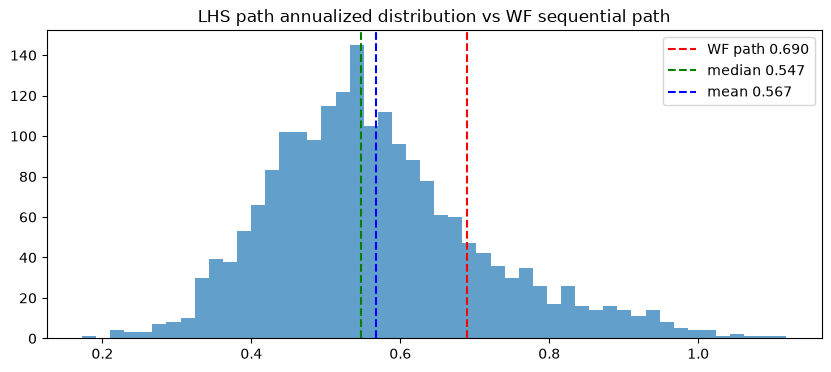

In [16]:
# 年化分布
path_anns = np.array([MultiPeriodPortfolio(sample).cumulative_returns[-1] for sample in samples])

wf_ann = 0.69
print(f"LHS多路径分布({len(path_anns)}条): 均值 {path_anns.mean():.4f} | 中位 {np.median(path_anns):.4f} | "
      f"5% {np.percentile(path_anns,5):.4f} | 95% {np.percentile(path_anns,95):.4f}")
print(f"WF真实路径: {wf_ann:.4f} | 分布中 {(wf_ann-path_anns.mean())/path_anns.std():.2f}σ | "
      f"分位 {(path_anns < wf_ann).mean():.1%}")

plt.figure(figsize=(10,4))
plt.hist(path_anns, bins=50, alpha=0.7)
plt.axvline(x=wf_ann, c='red', ls='--', label=f'WF path {wf_ann:.3f}')
plt.axvline(x=np.median(path_anns), c='green', ls='--', label=f'median {np.median(path_anns):.3f}')
plt.axvline(x=np.mean(path_anns), c='blue', ls='--', label=f'mean {np.mean(path_anns):.3f}')
plt.legend(); plt.title('LHS path annualized distribution vs WF sequential path'); plt.show()

#### fasted walkforward + CPCV

In [ ]:
res, paths = fasted_walkforward_cpcv(
    X, train_size=252*3, test_size=252, n_folds=8, n_test_folds=2
)

In [ ]:
Population(paths[0][0]).plot_cumulative_returns()

In [ ]:
all_test_parts = []
for i in range(7):
    part_paths = []
    for j in range(7):
        part_paths.append(paths[i][j][-2])
    all_test_parts.append(part_paths)
    part_paths = []
    for j in range(7):
        part_paths.append(paths[i][j][-1])
    all_test_parts.append(part_paths)

In [ ]:
Population(all_test_parts[-1]).plot_cumulative_returns()

In [ ]:
samples = discrete_lhs_safe(all_test_parts, 1000)

In [ ]:
Population([MultiPeriodPortfolio(sample, compounded=False) for sample in samples]).plot_cumulative_returns()